# MERRA-2 Masking (without streaming)

Ideally, we could run this full analysis by simply streaming data from Cryocloud. However, streaming capabilities don't really seem to be up to the task yet (cloud-enabled datasets are all daily data for the entire globe for all variables, not very efficient to stream!), although they are useful for smaller studies nonetheless. Anyway, while we wait for the streaming capabilities to improve, we instead opt to download all of the relevant MERRA-2 data and directly mask into that downloaded data to save on time. 

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import xarray as xr
from tqdm import tqdm
import dask

repo_dir = str(Path(os.getcwd()).parents[0])
os.chdir(repo_dir + '/scripts/')
from utils import display_catalog

home_dir = str(Path(os.getcwd()).parents[0])

scratch_path = '/pscratch/sd/j/jbbutler/merra2_data/'

In [2]:
# load up all of the dataframes by year, and then concatenate into one big one
df_path = home_dir + '/data/ar_database/dataframes/'
fnames = os.listdir(df_path)
df_list = []

for fname in fnames:
    df_list.append(pd.read_hdf(df_path + fname))
    
dataframe = pd.concat(df_list)

In [3]:
cell_areas = xr.open_dataset('~/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
cell_areas = cell_areas.cell_area
cell_areas = cell_areas.assign_coords(lat=cell_areas.lat.round(5), lon=cell_areas.lon.round(5))

ais_mask = xr.open_dataset('~/extreme_antarctic_ARs/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc')
ais_mask = ais_mask > 0
ais_mask = ais_mask.assign_coords(lat=ais_mask.lat.round(5), lon=ais_mask.lon.round(5))

In [14]:
precip = xr.load_dataset('/pscratch/sd/j/jbbutler/merra2_data_precip_ivt/tavg1_2d_int_Nx.19980608.nc4.nc4')

In [15]:
precip = precip.assign_coords(time=precip.time - np.timedelta64(30, 'm'))
precip

<xarray.Dataset> Size: 21MB
Dimensions:  (time: 24, lat: 95, lon: 576)
Coordinates:
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 192B 1998-06-08 ... 1998-06-08T23:00:00
Data variables:
    PRECLS   (time, lat, lon) float32 5MB 0.0 0.0 0.0 ... 6.894e-08 3.394e-08
    VFLXQV   (time, lat, lon) float32 5MB -2.987 -2.987 -2.987 ... -132.6 -157.8
    PRECCU   (time, lat, lon) float32 5MB 0.0 0.0 0.0 ... 2.305e-08 2.559e-06
    PRECSN   (time, lat, lon) float32 5MB 9.592e-07 9.69e-07 ... 0.0 0.0
Attributes: (12/32)
    History:                           Original file generated: Mon Nov 24 14...
    Comment:                           GMAO filename: d5124_m2_jan91.tavg1_2d...
    Filename:                          MERRA2_200.tavg1_2d_int_Nx.19980608.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    RangeBeginningDate:                1998-06-08
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   1998-06-08
    RangeEndingTime:                   23:59:59.000000
    DODS_EXTRA.Unlimited_Dimension:    time
    history:                           2024-10-29 21:53:40 GMT Hyrax-1.16.3 h...

In [16]:
precip['PRECSN'].resample(time='3h').sum()

<xarray.DataArray 'PRECSN' (time: 8, lat: 95, lon: 576)> Size: 2MB
array([[[2.6825096e-06, 2.6289795e-06, 2.6289795e-06, ...,
         5.5603932e-06, 2.7003530e-06, 2.7003530e-06],
        [2.3327325e-06, 2.3327325e-06, 2.3327325e-06, ...,
         2.2285226e-06, 2.3049433e-06, 2.3327325e-06],
        [9.8550777e-07, 1.1304245e-06, 1.1304245e-06, ...,
         9.8550777e-07, 9.8550777e-07, 9.8550777e-07],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[5.9036010e-06, 5.6125737e-06, 5.6125737e-06, ...,
         7.3354040e-06, 6.0006105e-06, 6.0006105e-06],
        [4.6779151e-06, 4.6779151e-06, 4.6779151e-06, ...,
         4.2204692e-06, 4.5559300e-06, 4.6779151e-06],
        [1.1557410e-06, 1.3212648e-06, 1.3212648e-06, ...,
         1.1557410e-06, 1.1557410e-06, 1.1557410e-06],
...
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[4.5176840e-08, 4.1941764e-08, 4.1941764e-08, ...,
         3.9602014e-08, 4.6255199e-08, 4.6255199e-08],
        [4.7864937e-06, 4.7864937e-06, 4.7864937e-06, ...,
         5.5489631e-06, 4.9898190e-06, 4.7864937e-06],
        [7.9206247e-06, 8.1832140e-06, 8.1832140e-06, ...,
         7.9206247e-06, 7.9206247e-06, 7.9206247e-06],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 64B 1998-06-08 ... 1998-06-08T21:00:00
Attributes:
    long_name:       snowfall
    units:           kg m-2 s-1
    fmissing_value:  1000000000000000.0
    standard_name:   snowfall
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]
    origname:        PRECSN
    fullnamepath:    /PRECSN

## Compute Area/Durational Quantities

In [372]:
def compute_max_area(ar_da, ais_da=None):
    
    ar_da_rounded = ar_da.assign_coords(lat=ar_da.lat.round(5), lon=ar_da.lon.round(5))
    
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=ar_da_rounded.lat, lon=ar_da_rounded.lon).Zwallybasins
        storm_da_subset = ar_da_rounded.where(storm_ais_mask, 0)
    else:
        storm_da_subset = ar_da_rounded.copy()
    
    grid_area_storm = cell_areas.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    max_area = float(storm_da_subset.dot(grid_area_storm).max().values/(1000**2))
    
    return max_area

def compute_max_southward_extent(ar_da):
    ar_da_rounded = ar_da.assign_coords(lat=ar_da.lat.round(5), lon=ar_da.lon.round(5))
    return np.min(ar_da.lat.values)

def compute_mean_area(ar_da, ais_da=None):
    
    ar_da_rounded = ar_da.assign_coords(lat=ar_da.lat.round(5), lon=ar_da.lon.round(5))
    
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=ar_da_rounded.lat, lon=ar_da_rounded.lon).Zwallybasins
        storm_da_subset = ar_da_rounded.where(storm_ais_mask, 0)
    else:
        storm_da_subset = ar_da_rounded.copy()
    
    grid_area_storm = cell_areas.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    mean_area = float(storm_da_subset.dot(grid_area_storm).mean().values/(1000**2))
    return mean_area

def compute_cumulative_spacetime(ar_da, ais_da=None):
    
    ar_da_rounded = ar_da.assign_coords(lat=ar_da.lat.round(5), lon=ar_da.lon.round(5))
    
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=ar_da_rounded.lat, lon=ar_da_rounded.lon).Zwallybasins
        storm_da_subset = ar_da_rounded.where(storm_ais_mask, 0)
    else:
        storm_da_subset = ar_da_rounded.copy()
    
    grid_area_storm = cell_areas.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    cumulative_area = float((3*storm_da_subset.dot(grid_area_storm)).sum().values/((1000**2)*24))
    return cumulative_area

def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

In [211]:
dataframe['max_area'] = dataframe['data_array'].apply(compute_max_area)
dataframe['mean_area'] = dataframe['data_array'].apply(compute_mean_area)
dataframe['mean_landfalling_area'] = dataframe['data_array'].apply(lambda x: compute_mean_area(x, ais_mask))
dataframe['cumulative_landfalling_area'] = dataframe['data_array'].apply(lambda x: compute_cumulative_spacetime(x, ais_mask))
dataframe['duration'] = dataframe['data_array'].apply(compute_duration)
dataframe['start_date'] = dataframe['data_array'].apply(add_start_date)
dataframe['end_date'] = dataframe['data_array'].apply(add_end_date)
dataframe['max_south_extent'] = dataframe['data_array'].apply(compute_max_southward_extent)

## Compute MERRA-2 Quantities

In [542]:
def compute_cumulative(storm_da, var_da, area_da, ais_da=None):
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()

    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)

    storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    amt_per_sec = storm_cell_areas.dot((storm_da_subset*var_da_subset))
    cumulative_storm_val = float((amt_per_sec*3*60*60).sum())

    return cumulative_storm_val

def compute_max_intensity(storm_da, var_da, area_da, ais_da=None):
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()
        
    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    max_intensity_val = float((storm_da_subset*var_da_subset).max())

    return max_intensity_val

def compute_min_SLP(storm_da, var_da, area_da, ais_da):
    
    storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
    storm_ocean_mask = np.logical_not(storm_ais_mask)
    storm_da_ais = storm_da.where(storm_ais_mask, 0)
    storm_da_ocean = storm_da.where(storm_ocean_mask, 0)
    
    var_da_subset = var_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)
      
    first_day = (storm_da_ocean*var_da_subset).sel(time=first_landfall).values
    min_slp = np.min(first_day[first_day > 0], initial=99999999)

    return min_slp

def compute_average(storm_da, var_da, area_da, ais_da=None):
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()

    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)

    storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    tot_area = storm_da_subset.dot(storm_cell_areas)
    avg_storm_val = float((storm_cell_areas.dot(storm_da_subset*var_da_subset)/tot_area).mean())

    return avg_storm_val

In [543]:
def grab_MERRA2_files(storm_da, ticker):
    
    dates = np.unique(storm_da.time.dt.date.values)

    fnames = []
    for date in dates:
        date_str = date.strftime('%Y%m%d')
        fname = ticker + '.' + date_str + '.nc4.nc4'
        fnames.append(fname)

    return fnames

def compute_raw_summaries(storm_da, func_vars_dict, cell_areas, ticker, ivt=False):
    
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    fnames = grab_MERRA2_files(storm_da, ticker)
    
    var_lst = np.unique(np.array(list(func_vars_dict.keys()))[:,1])

    ds_lst = []
    for fname in fnames:
        ds = xr.open_dataset(scratch_path + fname)
        ds_lst.append(ds[var_lst].sel(time = ds.time.dt.hour % 3 == 0))

    obs_ds = xr.concat(ds_lst, dim='time')
    if ivt:
        obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5), time=obs_ds.time - np.timedelta64(30, 'm'))
    else:
        obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))

    summaries = []
    for key, func in func_vars_dict.items():
        single_var_da = obs_ds[key[1]]
        summaries.append(func(storm_da, single_var_da, cell_areas))

    return summaries

In [544]:
def compute_anomaly_summaries(storm_da, func_vars_dict, climatology_dict, cell_areas, ticker):
    
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    fnames = grab_MERRA2_files(storm_da, ticker)
    var_lst = np.unique(np.array(list(func_vars_dict.keys()))[:,1])
    
    ds_lst = []
    for fname in fnames:
        ds = xr.open_dataset(scratch_path + fname)
        ds_lst.append(ds[var_lst].sel(time = ds.time.dt.hour % 3 == 0))
        
    obs_ds = xr.concat(ds_lst, dim='time')
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))
    
    summaries = []
    for key, func in func_vars_dict.items():
        actual_da = obs_ds[key[1]]
        climatology = climatology_dict[key[1]]
        climatology = climatology.assign_coords(lat=climatology.lat.round(5), lon=climatology.lon.round(5))
        single_var_da = xr.apply_ufunc(lambda da, clim: da-clim, actual_da.groupby('time.month'), climatology).drop_vars('month')
        single_var_da = single_var_da[key[1]]
        summaries.append(func(storm_da, single_var_da, cell_areas))
        
    return summaries   

In [545]:
# function to expand dataarray mask to include points which were within 24 hours of an AR point
# used to get a better assessment of precip due to an AR
def augment_storm_da(storm_da):
    
    start = storm_da.time.values[0]
    end = storm_da.time.values[-1] + np.timedelta64(1, 'D')
    full_dates=pd.date_range(start, end, freq='3h')
    
    unincluded_times = set(np.array(full_dates)) - set(storm_da.time.values)
    
    unincluded_array = np.zeros((len(unincluded_times), storm_da.shape[1], storm_da.shape[2]))
    unincluded_coords = {'time' : np.array(list(unincluded_times)), 'lat': storm_da.lat.values, 'lon': storm_da.lon.values}
    unincluded_da = xr.DataArray(unincluded_array, coords=unincluded_coords)
    
    augmented_da = xr.concat([storm_da, unincluded_da], dim='time')
    augmented_da = augmented_da.rolling(time=8, min_periods=1).max()
    
    return augmented_da

In [652]:
def compute_precip_summaries(storm_da, cell_areas, agg_func):
    
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    augmented_da = augment_storm_da(storm_da)
    
    fnames = grab_MERRA2_files(augmented_da, 'tavg1_2d_int_Nx')
    
    scratch_path = '/pscratch/sd/j/jbbutler/merra2_data_precip_ivt/'
    var_lst = ['PRECLS', 'PRECCU', 'PRECSN']
    
    ds_lst = []
    for fname in fnames:
        ds = xr.open_dataset(scratch_path + fname)
        ds_lst.append(ds[var_lst].sel(time = ds.time.dt.hour % 3 == 0))
        
    obs_ds = xr.concat(ds_lst, dim='time')
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5), time=obs_ds.time - np.timedelta64(30, 'm'))
    
    summaries = []
    # compute aggregate rainfall
    obs_ds['tot_rainfall'] = obs_ds['PRECCU'] + obs_ds['PRECLS']
    summaries.append(agg_func(augmented_da, obs_ds['tot_rainfall'], cell_areas))
    # compute aggregate snowfall
    summaries.append(agg_func(augmented_da, obs_ds['PRECSN'], cell_areas))
    
    return summaries

In [331]:
climatology_t2m = xr.load_dataset('/pscratch/sd/j/jbbutler/merra2_monthly_data/t2m_climatology.nc')
climatology_dict = {'T2M': climatology_t2m}

### Compute Quantities from `inst1_2d_asm_Nx`

In [657]:
ticker = 'inst1_2d_asm_Nx'

func_vars_dict = {('max_T2m_ais', 'T2M'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, var_da, area_da, ais_mask),
                  ('avg_V10m_ais', 'V10M'): lambda storm_da, var_da, area_da: compute_average(storm_da, -var_da, area_da, ais_mask),
                  ('max_V10m_ais', 'V10M'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, -var_da, area_da, ais_mask),
                  ('avg_V10m', 'V10M'): lambda storm_da, var_da, area_da: compute_average(storm_da, -var_da, area_da),
                  ('max_V10m', 'V10M'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, -var_da, area_da),
                  ('avg_IWV_ais', 'TQV'): lambda storm_da, var_da, area_da: compute_average(storm_da, var_da, area_da, ais_mask),
                  ('max_IWV_ais', 'TQV'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, var_da, area_da, ais_mask),
                  ('avg_IWV', 'TQV'): lambda storm_da, var_da, area_da: compute_average(storm_da, var_da, area_da),
                  ('max_IWV', 'TQV'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, var_da, area_da),
                  ('landfalling_SLP', 'SLP'): lambda storm_da, var_da, area_da: compute_min_SLP(storm_da, var_da, area_da, ais_mask)}

func_vars_dict_anomaly = {('max_T2M_anomaly_ais', 'T2M'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, var_da, area_da, ais_mask)}

climatology_t2m = xr.load_dataset('/pscratch/sd/j/jbbutler/merra2_monthly_data/t2m_climatology.nc')
climatology_dict = {'T2M': climatology_t2m}

In [347]:
landfalling_storms = dataframe[dataframe.is_landfalling]

In [348]:
summaries_lst = []

for i in tqdm(range(landfalling_storms.shape[0])):
    
    storm = landfalling_storms.iloc[i].data_array
    summaries = compute_raw_summaries(storm, func_vars_dict, cell_areas, ticker)
    summaries_anomaly = compute_anomaly_summaries(storm, func_vars_dict_anomaly, climatology_dict, cell_areas, ticker)
    
    summaries = summaries + summaries_anomaly
    summaries_lst.append(summaries)
    

  0%|          | 12/2988 [00:07<32:28,  1.53it/s]


KeyboardInterrupt: 

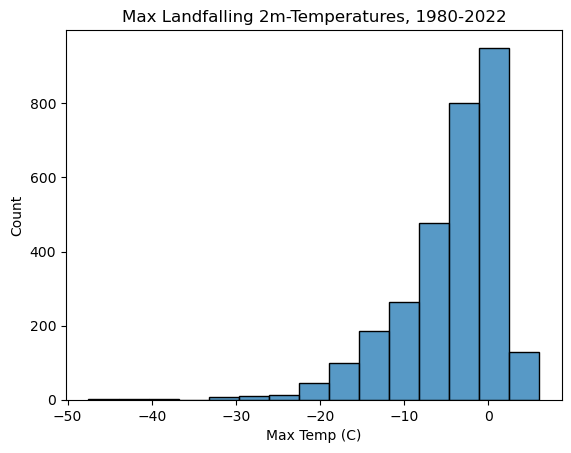

In [142]:
import matplotlib.pyplot as plt
sns.histplot(data=landfalling_storms, x='max_temp', bins=15);
plt.title('Max Landfalling 2m-Temperatures, 1980-2022')
plt.xlabel('Max Temp (C)')
plt.savefig('/global/u1/j/jbbutler/extreme_antarctic_ARs/plots/landfalling_temp_hist.png')

### Compute Quantities from `tavg1_2d_int_Nx`

In [655]:
ticker = 'tavg1_2d_int_Nx'

func_vars_dict = {('avg_vIVT_ais', 'VFLXQV'): lambda storm_da, var_da, area_da: compute_average(storm_da, -var_da, area_da, ais_mask),
                  ('max_vIVT_ais', 'VFLXQV'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, -var_da, area_da, ais_mask),
                  ('avg_vIVT', 'VFLXQV'): lambda storm_da, var_da, area_da: compute_average(storm_da, -var_da, area_da),
                  ('max_vIVT', 'VFLXQV'): lambda storm_da, var_da, area_da: compute_max_intensity(storm_da, -var_da, area_da)}

In [656]:
summaries_lst = []

for i in tqdm(range(landfalling_storms.shape[0])):
    
    storm = landfalling_storms.iloc[i].data_array
    summaries = compute_precip_summaries(storm, cell_areas, lambda storm_da, var_da, area_da: compute_cumulative(storm_da, var_da, area_da, ais_mask))
    summaries_lst.append(summaries)

 58%|█████▊    | 1732/2988 [16:15<11:47,  1.78it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/j/jbbutler/merra2_data_precip_ivt/tavg1_2d_int_Nx.20230101.nc4.nc4'

In [667]:
hello = pd.read_hdf('~/extreme_antarctic_ARs/data/ar_database/dataframes/landfalling_storm_quantities_df.h5')

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_V10m,max_V10m,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,landfalling_SLP,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
2733,,True,1219813.707482,1188527.781133,567878.092915,141969.523229,0 days 06:00:00,1995-01-07 03:00:00,1995-01-07 06:00:00,-76.000000,274.629913,0.853522,8.889969,2.709316,10.033691,5.324115,14.543134,10.465161,20.789228,97207.593750,7.346375,56.887406,179.231766,138.832279,347.207367,102952232308.672241,1334106613365.135010
2734,,True,467035.576292,403237.485376,403237.485376,201618.742688,0 days 12:00:00,1995-01-08 21:00:00,1995-01-09 06:00:00,-79.000000,270.317108,-1.514148,4.896917,-1.514148,4.896917,2.303332,6.131917,2.303332,6.131917,100000000.000000,10.230209,13.987385,36.072113,13.987385,36.072113,1134.990017,797381048235.805908
2735,,True,964372.186669,795660.065030,58952.144193,29476.072097,0 days 12:00:00,1995-01-08 21:00:00,1995-01-09 06:00:00,-71.500000,272.077332,-3.792203,1.517767,8.508035,15.313753,7.438242,9.868498,12.381610,23.477619,96750.773438,1.650452,48.193964,96.928833,176.964111,377.114990,0.000000,308900595474.923523
2736,,True,824849.341249,685325.571848,54340.837391,20377.814022,0 days 12:00:00,1995-01-09 12:00:00,1995-01-09 21:00:00,-69.000000,269.943512,-8.400123,0.000000,7.713524,14.913183,6.269894,11.474287,18.774849,29.065453,97191.843750,0.218964,58.555097,102.934189,348.912328,645.732300,0.000000,806163282556.473145

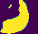